In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

import joblib

PROJ = Path.cwd().parents[0]
DATA_PROCESSED = PROJ / "data" / "processed"
MODELS_DIR = PROJ / "models"
REPORTS = PROJ / "reports"
FIGS = REPORTS / "figures"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True, parents=True)
FIGS.mkdir(exist_ok=True, parents=True)

# Load processed splits
X_train = np.load(DATA_PROCESSED / "X_train.npy")
X_val   = np.load(DATA_PROCESSED / "X_val.npy")
X_test  = np.load(DATA_PROCESSED / "X_test.npy")
y_train = pd.read_csv(DATA_PROCESSED / "y_train.csv").squeeze()
y_val   = pd.read_csv(DATA_PROCESSED / "y_val.csv").squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / "y_test.csv").squeeze()

# Concatenate TRAIN+VAL for CV-based tuning (TEST stays untouched)
X_tune = np.concatenate([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

print("X_tune:", X_tune.shape, "| y_tune:", y_tune.shape, "| X_test:", X_test.shape)

X_tune: (425, 377) | y_tune: (425,) | X_test: (76, 377)


In [2]:
# Define models and grids
log_reg = LogisticRegression(max_iter=5000, class_weight="balanced")
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
gb = GradientBoostingClassifier(random_state=42)

# Parameter grids (keep modest to run fast)
param_grid_lr = {
    "C": [0.1, 1.0, 3.0, 10.0],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],  # liblinear supports l2
}

param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid_gb = {
    "n_estimators": [150, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3],
    "subsample": [1.0, 0.8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "f1_weighted"  # main objective

In [3]:
def grid_search(model, param_grid, name):
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    gs.fit(X_tune, y_tune)
    print(f"\n{name} best params:", gs.best_params_)
    print(f"{name} best CV {scoring}:", gs.best_score_)
    return gs

gs_lr = grid_search(log_reg, param_grid_lr, "LogReg")
gs_rf = grid_search(rf, param_grid_rf, "RandomForest")
gs_gb = grid_search(gb, param_grid_gb, "GradBoost")

# Collect validation-like holdout scores using original VAL set for fair comparison
def eval_on_val(estimator, name):
    preds = estimator.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="weighted")
    print(f"\n[name={name}] Val Accuracy={acc:.3f}, Val F1={f1:.3f}")
    return acc, f1

results = {
    "LogisticRegression": eval_on_val(gs_lr.best_estimator_, "LogisticRegression"),
    "RandomForest": eval_on_val(gs_rf.best_estimator_, "RandomForest"),
    "GradientBoosting": eval_on_val(gs_gb.best_estimator_, "GradientBoosting"),
}

pd.DataFrame([
    {"model": k, "val_acc": v[0], "val_f1": v[1]} for k, v in results.items()
]).sort_values(["val_f1","val_acc"], ascending=False)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



LogReg best params: {'C': 3.0, 'penalty': 'l2', 'solver': 'liblinear'}
LogReg best CV f1_weighted: 0.8295815750157927
Fitting 5 folds for each of 27 candidates, totalling 135 fits

RandomForest best params: {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 200}
RandomForest best CV f1_weighted: 0.8275816990217321
Fitting 5 folds for each of 24 candidates, totalling 120 fits

GradBoost best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
GradBoost best CV f1_weighted: 0.8169498727509079

[name=LogisticRegression] Val Accuracy=0.907, Val F1=0.880

[name=RandomForest] Val Accuracy=0.947, Val F1=0.949

[name=GradientBoosting] Val Accuracy=1.000, Val F1=1.000


,model,val_acc,val_f1
2,GradientBoosting,1.000000,1.000000
1,RandomForest,0.946667,0.948708
0,LogisticRegression,0.906667,0.879580


In [4]:
# Select best by (F1, then Accuracy)
best_name = max(results, key=lambda k: (results[k][1], results[k][0]))
print("Best model:", best_name)

best_map = {
    "LogisticRegression": gs_lr.best_estimator_,
    "RandomForest": gs_rf.best_estimator_,
    "GradientBoosting": gs_gb.best_estimator_,
}
best_estimator = best_map[best_name]

# Optional: calibrate probabilities (improves probability quality)
calibrated = CalibratedClassifierCV(best_estimator, method="sigmoid", cv=5)
calibrated.fit(X_tune, y_tune)
best_estimator = calibrated  # use calibrated version downstream
print("Applied probability calibration.")

Best model: GradientBoosting
Applied probability calibration.


In [5]:
# Recover feature names from the saved preprocessor
import joblib
pre = joblib.load(PROJ / "models" / "preprocessor.joblib")

# Transformers: [("num", numeric_pipe, num_cols), ("cat", categorical_pipe, cat_cols)]
num_cols = pre.transformers_[0][2]
cat_cols = pre.transformers_[1][2]
ohe = pre.transformers_[1][1].named_steps["encoder"]
ohe_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = list(num_cols) + ohe_names

print("Total features:", len(feature_names), "| matches matrix:", X_train.shape[1])

Total features: 377 | matches matrix: 377


In [6]:
# Permutation Importance on VAL set for interpretability
from sklearn.inspection import permutation_importance
imp = permutation_importance(best_estimator, X_val, y_val, n_repeats=20, random_state=42, scoring="f1_weighted")
importances = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": imp.importances_mean,
    "importance_std": imp.importances_std
}).sort_values("importance_mean", ascending=False)

topk = importances.head(20)
topk.to_csv(REPORTS / "top20_permutation_importance.csv", index=False)
print("Saved:", REPORTS / "top20_permutation_importance.csv")
topk

Saved: d:\Git\DepressionLevel\DepressionModelProject\reports\top20_permutation_importance.csv


,feature,importance_mean,importance_std
358,1. Have You Been Feeling Sad Most of The Time ...,0.067312,0.025166
357,1. Have You Been Feeling Sad Most of The Time ...,0.067253,0.024689
362,"3. Do You Feel Tired All The Time , Do You Fin...",0.057497,0.021219
360,2. Do You Feel Unhappy Even When You Do Your F...,0.048636,0.025222
359,2. Do You Feel Unhappy Even When You Do Your F...,0.044205,0.023254
361,"3. Do You Feel Tired All The Time , Do You Fin...",0.036407,0.019120
351,What is Your Age group?_26-35,0.026745,0.017438
375,10. Have you lost your appetite or found that ...,0.022628,0.014273
376,10. Have you lost your appetite or found that ...,0.022628,0.014273
369,7. Do you feel as if things won’t get better n...,0.022170,0.018716


c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\chathudu sahassara\AppDat

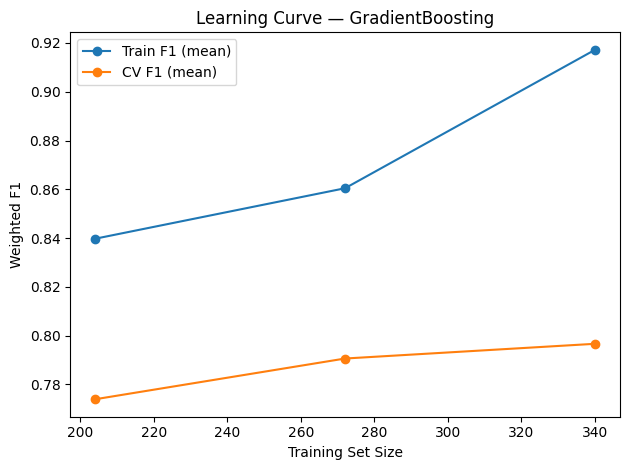

Saved figure: d:\Git\DepressionLevel\DepressionModelProject\reports\figures\learning_curve_GradientBoosting.png


In [7]:
# Learning Curve to see if more data would help
train_sizes, train_scores, val_scores = learning_curve(
    best_estimator, X_tune, y_tune, cv=5, scoring="f1_weighted",
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1, shuffle=True, random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker='o', label='Train F1 (mean)')
plt.plot(train_sizes, val_mean, marker='o', label='CV F1 (mean)')
plt.xlabel('Training Set Size')
plt.ylabel('Weighted F1')
plt.title(f'Learning Curve — {best_name}')
plt.legend()
fig_path = FIGS / f"learning_curve_{best_name.replace(' ', '_')}.png"
plt.tight_layout()
plt.savefig(fig_path)
plt.show()
print("Saved figure:", fig_path)

In [9]:
import json   # ← add this line at the top

# Final evaluation on TEST
preds_test = best_estimator.predict(X_test)
acc = accuracy_score(y_test, preds_test)
f1  = f1_score(y_test, preds_test, average="weighted")
print(f"[TEST] Accuracy={acc:.3f} | Weighted F1={f1:.3f}")
print(classification_report(y_test, preds_test))

# Save tuned model
safe = best_name.replace(" ", "")
model_path = MODELS_DIR / f"{safe}_tuned_calibrated.joblib"
import joblib
joblib.dump(best_estimator, model_path)
print("Saved model:", model_path)

# Save a tiny model card
card = {
    "best_model": best_name,
    "scoring": "f1_weighted (tie: accuracy)",
    "test_accuracy": float(acc),
    "test_weighted_f1": float(f1),
    "notes": "Preprocessor fitted on train only in Step 2; CV used TRAIN+VAL; TEST untouched. Probabilities calibrated (sigmoid)."
}
with open(MODELS_DIR / "model_card.json", "w") as f:
    json.dump(card, f, indent=2)
print("Saved model card:", MODELS_DIR / "model_card.json")


[TEST] Accuracy=0.868 | Weighted F1=0.807
                     precision    recall  f1-score   support

    Mild Depression       0.00      0.00      0.00         7
Moderate Depression       0.00      0.00      0.00         3
      No Depression       0.88      1.00      0.94        58
  Severe Depression       0.80      1.00      0.89         8

           accuracy                           0.87        76
          macro avg       0.42      0.50      0.46        76
       weighted avg       0.75      0.87      0.81        76

Saved model: d:\Git\DepressionLevel\DepressionModelProject\models\GradientBoosting_tuned_calibrated.joblib
Saved model card: d:\Git\DepressionLevel\DepressionModelProject\models\model_card.json


c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to